In [3]:
"""
Analysis of D+ curves computed across quartiles of B. Produces figures.
"""

'\nAnalysis of D+ curves computed across quartiles of B. Produces figures.\n'

In [4]:
import numpy as np
import dpluspy
import pickle

import matplotlib.pyplot as plt

In [5]:
# Bootstrap
def run_bootstrap(in_fnames, out_fname):
    sums = {}
    for fname in in_fnames:
        with open(fname, "rb") as fin:
            chrom_sums = pickle.load(fin)
        sums.update(chrom_sums)

    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]

    replicates = dpluspy.bootstrapping.get_bootstrap_reps(
        sums, num_reps=100, weighted=True, aggregate=True)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    means = dpluspy.bootstrapping.weighted_means_across_regions(
        sums, aggregate=True)
    
    data = {
        "means": means, 
        "varcovs": varcovs, 
        "bins": bins, 
        "pop_ids": pop_ids,
        "replicates": replicates
    }
    with open(out_fname, "wb") as fout:
        pickle.dump(data, fout)
    return


for ii in range(4):
    fnames = [f"data/sums/quartile_{ii}/stats_B_strat_quartile_{ii}_chr{j}.pkl" 
              for j in range(1, 23)]
    out_fname = f"data/stats/stats_B_strat_quartile_{ii}.pkl"
    run_bootstrap(fnames, out_fname)

fnames = [f"data/sums/intergenic/stats_intergenic_chr{j}.pkl" 
          for j in range(1, 23)]
out_fname = f"data/stats/stats_intergenic_{ii}.pkl"
run_bootstrap(fnames, out_fname)

In [6]:
# Load statistics
pops_to_plot = ["Vindija", "Denisova", "UstIshim", "Yoruba1", "Yoruba3"]
means = []
varcovs = []

fname = f"data/stats/stats_intergenic_{ii}.pkl"
pop_ids, bins, _means, _varcovs = dpluspy.inference.load_stats(
    fname, to_pops=pops_to_plot)
means.append(_means)
varcovs.append(_varcovs)

for ii in range(4):
    fname = f"data/stats/stats_B_strat_quartile_{ii}.pkl"
    pop_ids, bins, _means, _varcovs = dpluspy.inference.load_stats(
        fname, to_pops=pops_to_plot)
    means.append(_means)
    varcovs.append(_varcovs)

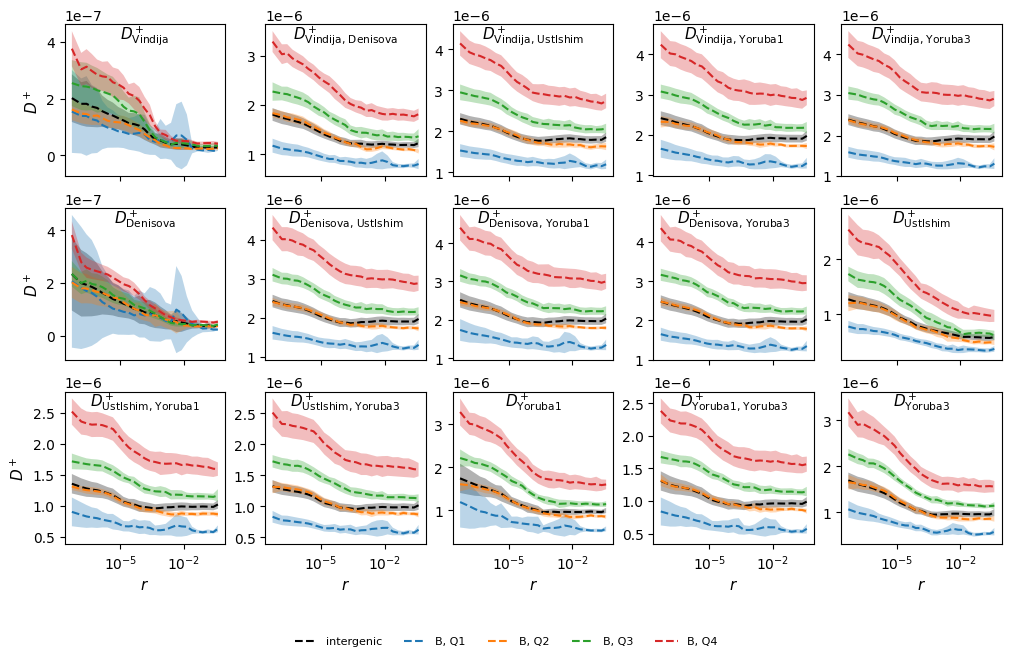

In [7]:
# Plot a summary for five samples
colors = ["black", "tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = ["intergenic", "B, Q1", "B, Q2", "B, Q3", "B, Q4"]
dpluspy.plotting.plot_d_plus_curves(means=means, varcovs=varcovs, bins=bins,
    pop_ids=pop_ids, labels=labels, colors=colors, out="figures/fig_summary.pdf")

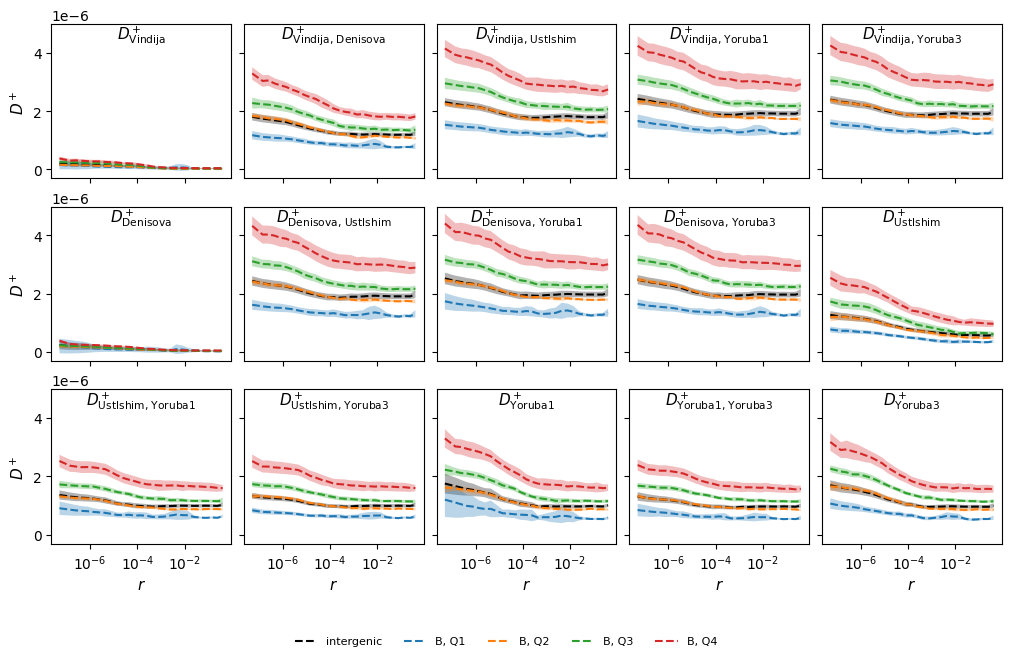

In [8]:
# Plot the same summary with shared y-axis
colors = ["black", "tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = ["intergenic", "B, Q1", "B, Q2", "B, Q3", "B, Q4"]
dpluspy.plotting.plot_d_plus_curves(means=means, varcovs=varcovs, bins=bins,
    pop_ids=pop_ids, labels=labels, colors=colors, sharey=True,
    out="figures/fig_shared_y.pdf")